# P07 Visualization with Pandas

Main Reference: https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html

## Loading vaccination data

* https://ourworldindata.org/covid-vaccinations
* https://github.com/owid/covid-19-data/tree/master/public/data
* https://github.com/owid/covid-19-data/blob/master/public/data/owid-covid-data.csv

In [1]:
import pandas as pd
raw = pd.read_csv("https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv")

### Observing data

In [2]:
raw.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [3]:
set(raw.continent)

{'Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America', nan}

### Filtering data

In [88]:
df_asia = raw.loc[raw['continent']=="Asia"]
print(set(df_asia.location))
print(len(set(df_asia.location)))

{'Georgia', 'Malaysia', 'Azerbaijan', 'Turkey', 'Kyrgyzstan', 'Iran', 'Vietnam', 'Japan', 'Cambodia', 'Jordan', 'Palestine', 'Thailand', 'China', 'Brunei', 'Qatar', 'Armenia', 'Mongolia', 'Pakistan', 'Timor', 'Uzbekistan', 'Sri Lanka', 'Hong Kong', 'Bahrain', 'Taiwan', 'Bangladesh', 'United Arab Emirates', 'Singapore', 'Turkmenistan', 'Macao', 'Philippines', 'South Korea', 'Nepal', 'Oman', 'Saudi Arabia', 'Maldives', 'Lebanon', 'Bhutan', 'Iraq', 'Kuwait', 'Afghanistan', 'Northern Cyprus', 'Tajikistan', 'Indonesia', 'Syria', 'Myanmar', 'India', 'Yemen', 'Kazakhstan', 'Laos', 'Israel'}
50


In [101]:
df_tw = df_asia.loc[df_asia['location']=="Taiwan"]

In [102]:
df_tw

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
111625,TWN,Asia,Taiwan,2020-01-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
111626,TWN,Asia,Taiwan,2020-01-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
111627,TWN,Asia,Taiwan,2020-01-18,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
111628,TWN,Asia,Taiwan,2020-01-19,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
111629,TWN,Asia,Taiwan,2020-01-20,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112273,TWN,Asia,Taiwan,2021-10-25,16376.0,8.0,5.571,847.0,1.0,0.143,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
112274,TWN,Asia,Taiwan,2021-10-26,16380.0,4.0,5.286,847.0,0.0,0.143,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
112275,TWN,Asia,Taiwan,2021-10-27,16388.0,8.0,5.857,847.0,0.0,0.143,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN
112276,TWN,Asia,Taiwan,2021-10-28,16394.0,6.0,6.429,847.0,0.0,0.143,...,NaN,NaN,NaN,NaN,80.46,NaN,NaN,NaN,NaN,NaN


In [104]:
df_tw.dtypes

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
human_development_index                    float64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 65, dtype: object

In [106]:
type(list(df_tw.date)[0])

str

## line plot of time series

In [107]:
print(type(df_tw.date))
# <class 'pandas.core.series.Series'>


print(df_tw.date.dtype)
# object (str)

# Converting columns to datetime
df_tw['date'] = pd.to_datetime(df_tw.date)

print(df_tw.date.dtype)
# datetime64[ns]

<class 'pandas.core.series.Series'>
object
datetime64[ns]


/Users/jirlong/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


**args**
- `figsize=(10,5)`: The size in `figsize=(5,3)` is given in inches per (width, height). See https://stackoverflow.com/questions/51174691/how-to-increase-image-size-of-pandas-dataframe-plot

### by Pandas

<AxesSubplot:xlabel='date'>

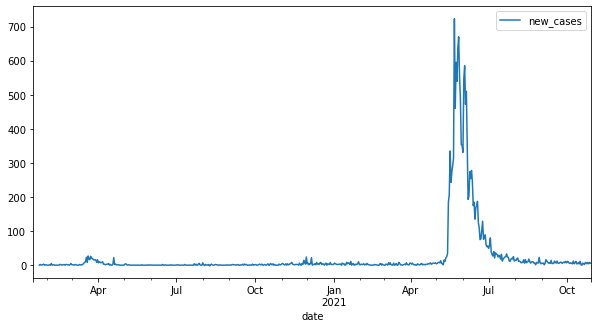

In [40]:
df_tw.plot(x="date", y="new_cases", figsize=(10, 5))

In [44]:
df1 = df.loc[df['location'].isin(["Taiwan", "Japan"])]
set(df1.location)

{'Japan', 'Taiwan'}

### Pivot to more columns

In [60]:
df_wide = df1.pivot(index="date", columns="location", values=["new_cases", "total_cases", "total_vaccinations_per_hundred"])
df_wide.columns

MultiIndex([(                     'new_cases',  'Japan'),
            (                     'new_cases', 'Taiwan'),
            (                   'total_cases',  'Japan'),
            (                   'total_cases', 'Taiwan'),
            ('total_vaccinations_per_hundred',  'Japan'),
            ('total_vaccinations_per_hundred', 'Taiwan')],
           names=[None, 'location'])

In [61]:
df_wide

new_cases        total_cases           \
location       Japan Taiwan       Japan   Taiwan   
date                                               
2020-01-16       NaN    NaN         NaN      NaN   
2020-01-17       NaN    NaN         NaN      NaN   
2020-01-18       NaN    NaN         NaN      NaN   
2020-01-19       NaN    NaN         NaN      NaN   
2020-01-20       NaN    NaN         NaN      NaN   
...              ...    ...         ...      ...   
2021-10-25     153.0    8.0   1717851.0  16376.0   
2021-10-26     314.0    4.0   1718165.0  16380.0   
2021-10-27     321.0    8.0   1718486.0  16388.0   
2021-10-28     278.0    6.0   1718764.0  16394.0   
2021-10-29     279.0    5.0   1719043.0  16399.0   

           total_vaccinations_per_hundred          
location                            Japan  Taiwan  
date                                               
2020-01-16                            NaN     NaN  
2020-01-17                            NaN     NaN  
2020-01-18                            NaN     NaN  
2020-01-19                            NaN     NaN  
2020-01-20                            NaN     NaN  
...                                   ...     ...  
2021-10-25                         147.54   95.51  
2021-10-26                            NaN   97.33  
2021-10-27                         148.15   99.09  
2021-10-28                         149.04  100.81  
2021-10-29                            NaN  102.62  

[653 rows x 6 columns]

In [62]:
df_wide.reset_index(inplace=True)
df_wide

date new_cases        total_cases           \
location                 Japan Taiwan       Japan   Taiwan   
0         2020-01-16       NaN    NaN         NaN      NaN   
1         2020-01-17       NaN    NaN         NaN      NaN   
2         2020-01-18       NaN    NaN         NaN      NaN   
3         2020-01-19       NaN    NaN         NaN      NaN   
4         2020-01-20       NaN    NaN         NaN      NaN   
..               ...       ...    ...         ...      ...   
648       2021-10-25     153.0    8.0   1717851.0  16376.0   
649       2021-10-26     314.0    4.0   1718165.0  16380.0   
650       2021-10-27     321.0    8.0   1718486.0  16388.0   
651       2021-10-28     278.0    6.0   1718764.0  16394.0   
652       2021-10-29     279.0    5.0   1719043.0  16399.0   

         total_vaccinations_per_hundred          
location                          Japan  Taiwan  
0                                   NaN     NaN  
1                                   NaN     NaN  
2                                   NaN     NaN  
3                                   NaN     NaN  
4                                   NaN     NaN  
..                                  ...     ...  
648                              147.54   95.51  
649                                 NaN   97.33  
650                              148.15   99.09  
651                              149.04  100.81  
652                                 NaN  102.62  

[653 rows x 7 columns]

### Visualizing by pandas

<AxesSubplot:xlabel='date'>

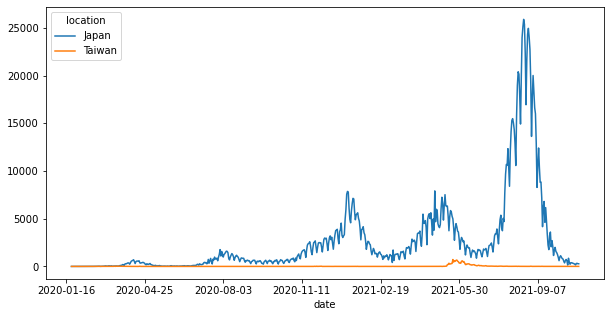

In [65]:
df_wide.plot(x="date", y="new_cases", figsize=(10, 5))

### More params
https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.DataFrame.plot.html

<AxesSubplot:xlabel='date'>

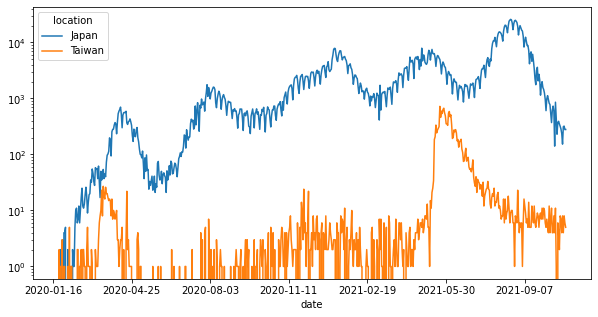

In [137]:
df_wide.plot(x="date", y="new_cases", figsize=(10, 5), logy=True)

In [144]:
df_wide.fillna(0, inplace=True)
df_wide.new_cases.Taiwan

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
648    8.0
649    4.0
650    8.0
651    6.0
652    5.0
Name: Taiwan, Length: 653, dtype: float64

### by plot_bokeh line plot with pandas_bokeh
- https://towardsdatascience.com/beautiful-and-easy-plotting-in-python-pandas-bokeh-afa92d792167
- https://patrikhlobil.github.io/Pandas-Bokeh/ (Document of Pandas-Bokeh)

In [152]:
# !pip install pandas_bokeh
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

You should consider upgrading via the '/Users/jirlong/opt/anaconda3/bin/python -m pip install --upgrade pip' command.


In [153]:
import pandas_bokeh
pandas_bokeh.output_notebook()

Loading BokehJS ...

In [163]:
df_wide2 = df_wide.copy()
df_wide2.columns = df_wide.columns.map('_'.join)
df_wide2

,date_,new_cases_Japan,new_cases_Taiwan,total_cases_Japan,total_cases_Taiwan,total_vaccinations_per_hundred_Japan,total_vaccinations_per_hundred_Taiwan
0,2020-01-16,0.0,0.0,0.0,0.0,0.00,0.00
1,2020-01-17,0.0,0.0,0.0,0.0,0.00,0.00
2,2020-01-18,0.0,0.0,0.0,0.0,0.00,0.00
3,2020-01-19,0.0,0.0,0.0,0.0,0.00,0.00
4,2020-01-20,0.0,0.0,0.0,0.0,0.00,0.00
...,...,...,...,...,...,...,...
648,2021-10-25,153.0,8.0,1717851.0,16376.0,147.54,95.51
649,2021-10-26,314.0,4.0,1718165.0,16380.0,0.00,97.33
650,2021-10-27,321.0,8.0,1718486.0,16388.0,148.15,99.09
651,2021-10-28,278.0,6.0,1718764.0,16394.0,149.04,100.81


In [168]:
df_wide2.plot_bokeh(
    kind='line',
    x='date_',
    y=['new_cases_Japan', 'new_cases_Taiwan']
)

Figure(id='3015', ...)

## Bar chart: vaccinating rate

In [83]:
df.dtypes

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
human_development_index                    float64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 65, dtype: object

In [120]:
df['date'] = pd.to_datetime(df.date)
print(df.date.dtype)

datetime64[ns]


/Users/jirlong/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [109]:
max(df.date)

Timestamp('2021-10-29 00:00:00')

In [132]:
import datetime
df_recent = df.loc[df['date'] == datetime.datetime(2021, 10, 28)]

### by pure pandas

<AxesSubplot:ylabel='location'>

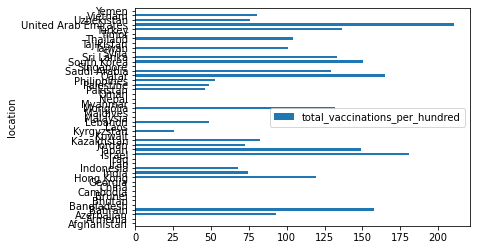

In [133]:
df_recent.columns
df_recent.plot.barh(x="location", y="total_vaccinations_per_hundred")

<AxesSubplot:ylabel='location'>

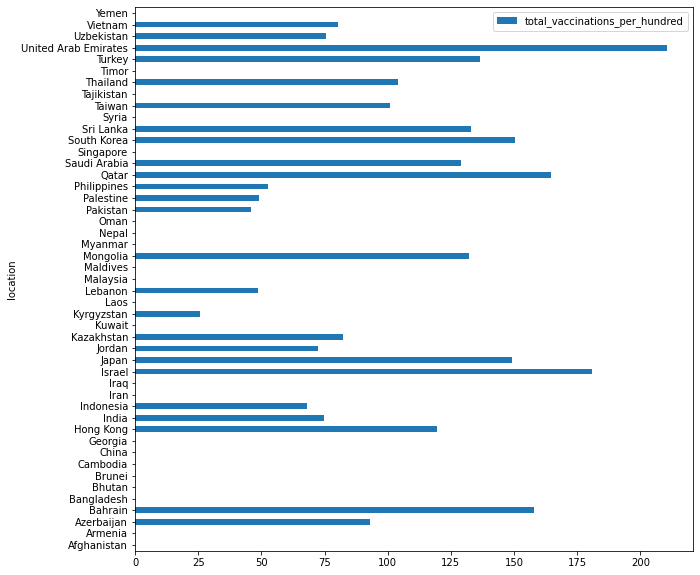

In [134]:
df_recent.plot.barh(x="location", y="total_vaccinations_per_hundred", figsize=(10, 10))

<AxesSubplot:ylabel='location'>

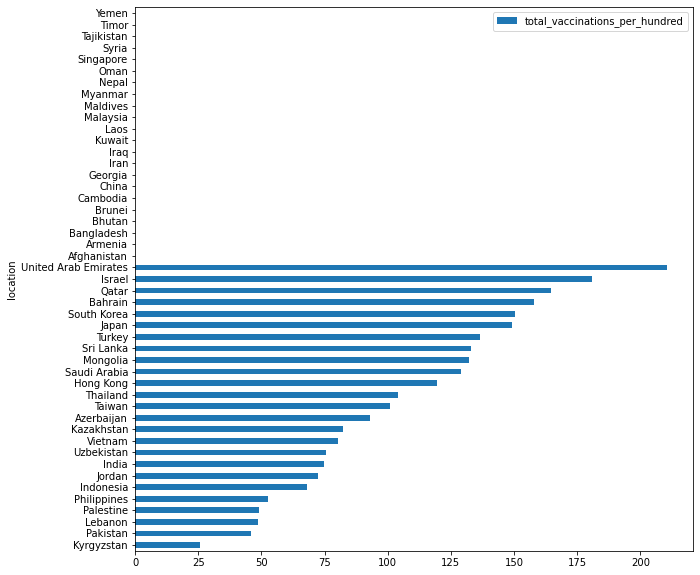

In [135]:
df_recent.sort_values('total_vaccinations_per_hundred', ascending=True).plot.barh(x="location", y="total_vaccinations_per_hundred", figsize=(10, 10))

<AxesSubplot:ylabel='location'>

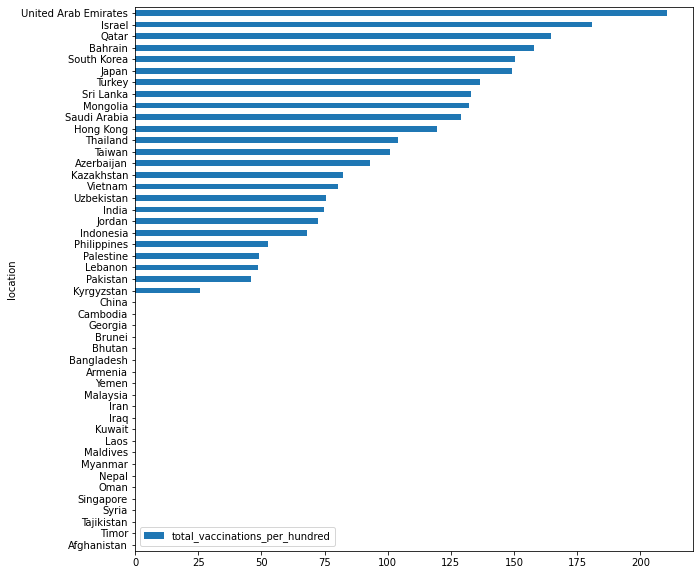

In [170]:
df_recent.fillna(0).sort_values('total_vaccinations_per_hundred', ascending=True).plot.barh(x="location", y="total_vaccinations_per_hundred", figsize=(10, 10))

### by plot_bokeh

In [172]:
df_recent.fillna(0).sort_values('total_vaccinations_per_hundred', ascending=True).plot_bokeh(kind="barh", 
                                                                                             x="location", 
                                                                                             y="total_vaccinations_per_hundred")

Figure(id='3403', ...)